In [1]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    np.random.default_rng(seed=seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('random seed done')


seed_everything(42)

random seed done


In [4]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
OPTIONS

{'network': 'unet3d_v2',
 'dataset': 'dataset_synthetic',
 'img_size': None,
 'lr': 0.001,
 'loss': 'dice_focal',
 'batch_size': 4,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 16}

In [5]:
IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')
IMG_SIZE, BATCH_SIZE

(None, 4)

In [6]:
df = pd.read_csv('../Dataset/DataBase.csv')
IMG_SIZE = ast.literal_eval(df['shape'].iloc[0])

OPTIONS['img_size'] = IMG_SIZE
df

,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,img_0000.npy,0.0,1.0,0.500493,0.213970,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
1,img_0001.npy,0.0,1.0,0.500305,0.213971,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
2,img_0002.npy,0.0,1.0,0.500420,0.207745,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
3,img_0003.npy,0.0,1.0,0.500660,0.209697,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
4,img_0004.npy,0.0,1.0,0.499853,0.210342,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
...,...,...,...,...,...,...,...,...,...,...
215,img_0215.npy,0.0,1.0,0.500554,0.213253,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
216,img_0216.npy,0.0,1.0,0.500970,0.210811,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
217,img_0217.npy,0.0,1.0,0.501456,0.210288,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...
218,img_0218.npy,0.0,1.0,0.499670,0.209216,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Searcher/Datas...,/home/grva-mint/Projects/Falhas/Searcher/Datas...


In [7]:
MULTICLASS = False
classes    = 1
classes

1

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


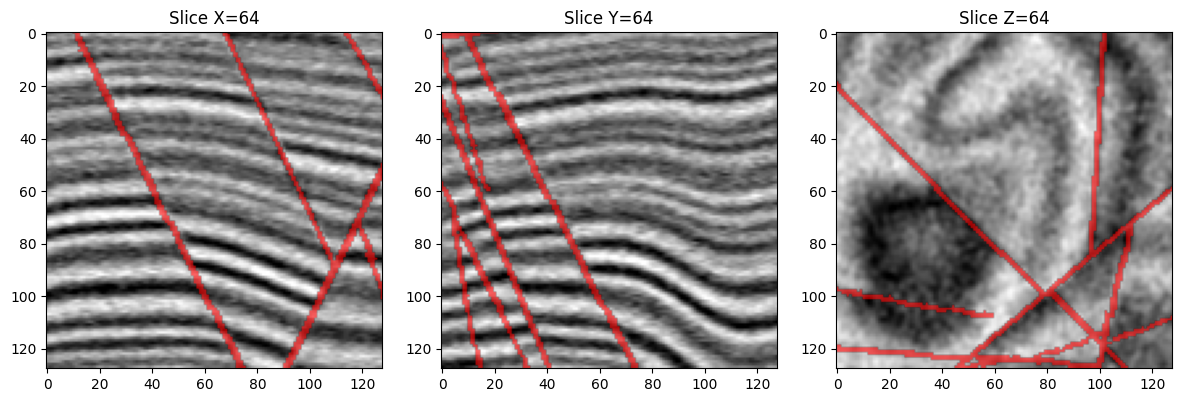

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


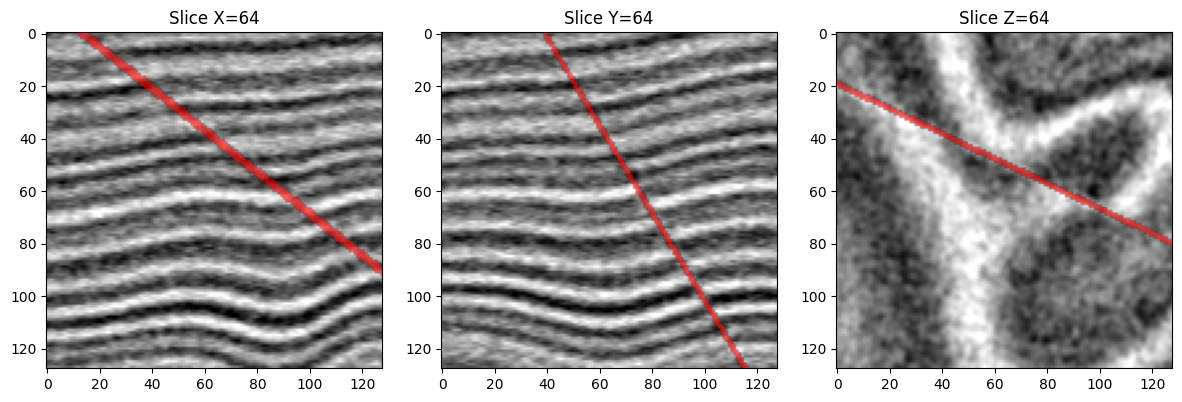

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


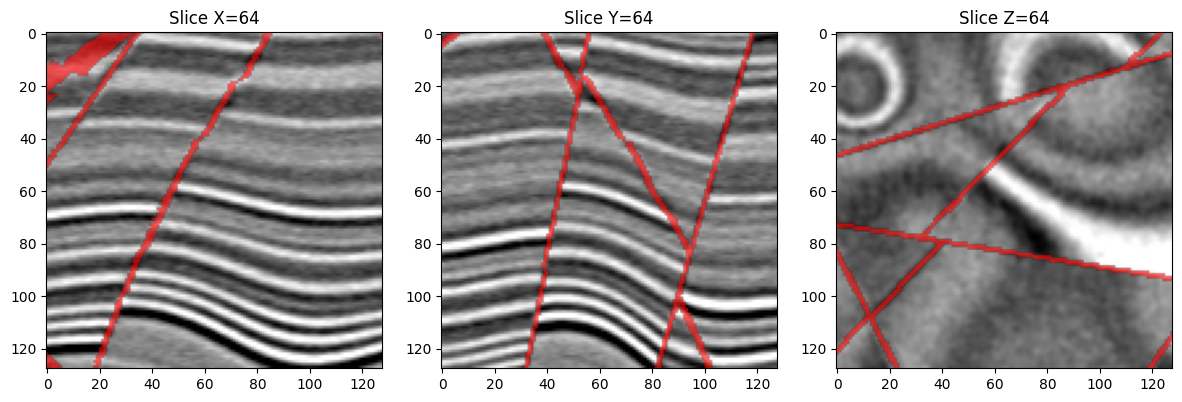

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


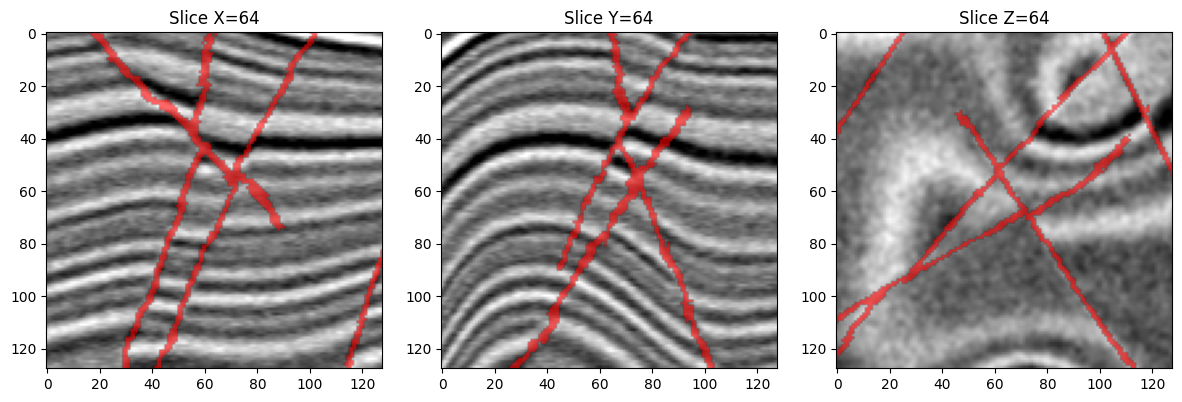

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


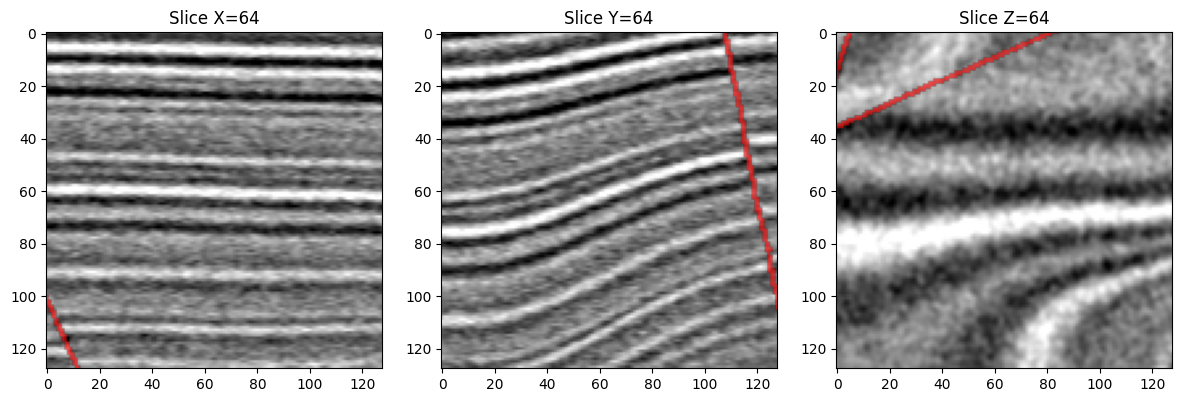

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


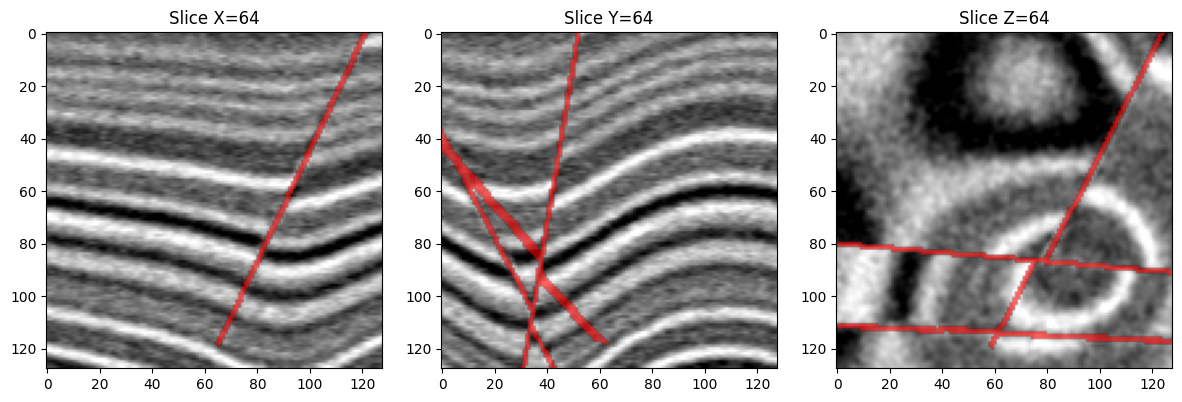

In [8]:
for index in range(6):
    img, msk = np.load(df.iloc[index].img_path), np.load(df.iloc[index].mask_path)
    print(f'img: {np.min(img), np.max(img)}')
    print(f'msk: {np.min(msk), np.max(msk)}')
    showTile(img=img, mask=msk)

# SPLITS DOS DADOS

In [9]:
VAL_SIZE  = 0.045454545454545456
TEST_SIZE = 0.045454545454545456
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [10]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
train_df, val_df = train_test_split(temp_df, test_size=VAL_SIZE, random_state=42)
del temp_df

OPTIONS['n_images'] = {'total': len(df), 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
OPTIONS['n_images']

{'total': 220, 'train': 200, 'val': 10, 'test': 10}

# MODELO

In [11]:
from Network.index import ModelNetwork

In [12]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': OPTIONS.get('img_size'),
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
}

print(model_options)
network = ModelNetwork(**model_options)
network.model

{'network': 'unet3d_v2', 'img_size': (128, 128, 128), 'classes': 1, 'channels': 1, 'dropout': 0.1, 'num_filters': 16, 'lr': 0.001}


Unet3D_V2(
  (enc1): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
      (act2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (pool): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout3d(p=0.025, inplace=False)
  )
  (enc2): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1),

In [13]:
network.classes

1

# DATASET

In [14]:
from torch.utils.data import Dataset
from Transforms.index import Compose

In [15]:
class CustomDataset(Dataset):
    def __init__(self, df, multiclass=False, augmentations=None):
        self.df = df.reset_index(drop=True)
        self.multiclass = multiclass
        self.augmentor  = Compose(augmentations) if augmentations else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        if self.augmentor:
            img, mask = self.augmentor(img, mask)

        img_tensor  = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


trainDataset = CustomDataset(
    df=train_df, 
    multiclass=MULTICLASS,
    augmentations=OPTIONS.get('augmentations')
)

valDataset = CustomDataset(
    df=val_df, 
    multiclass=MULTICLASS
)

testDataset = CustomDataset(
    df=test_df, 
    multiclass=MULTICLASS
)

# DATA LOADER

In [16]:
from torch.utils.data import DataLoader

In [17]:
NUM_WORKERS = 2

trainLoader = DataLoader(
    trainDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

valLoader = DataLoader(
    valDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

testLoader = DataLoader(
    testDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

xTrain Shape:  (128, 128, 128)
yTrain Shape:  (128, 128, 128)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [0 1]


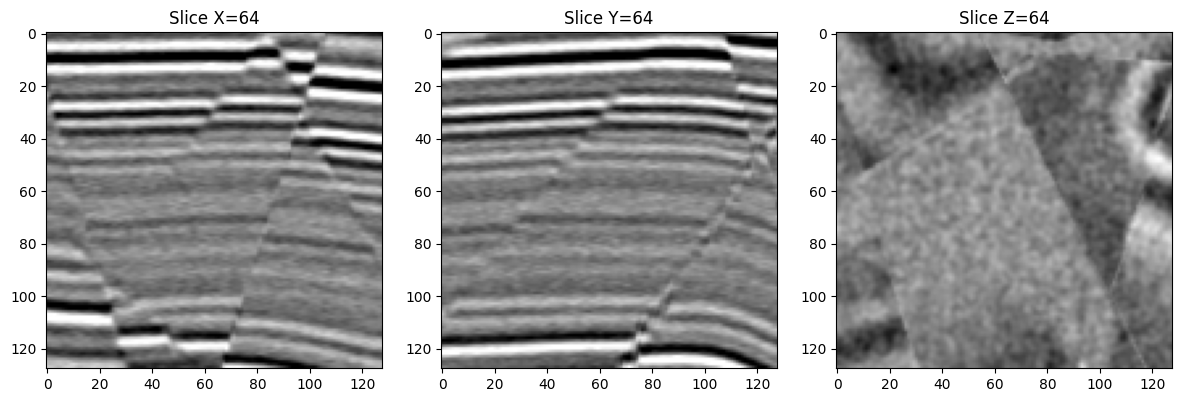

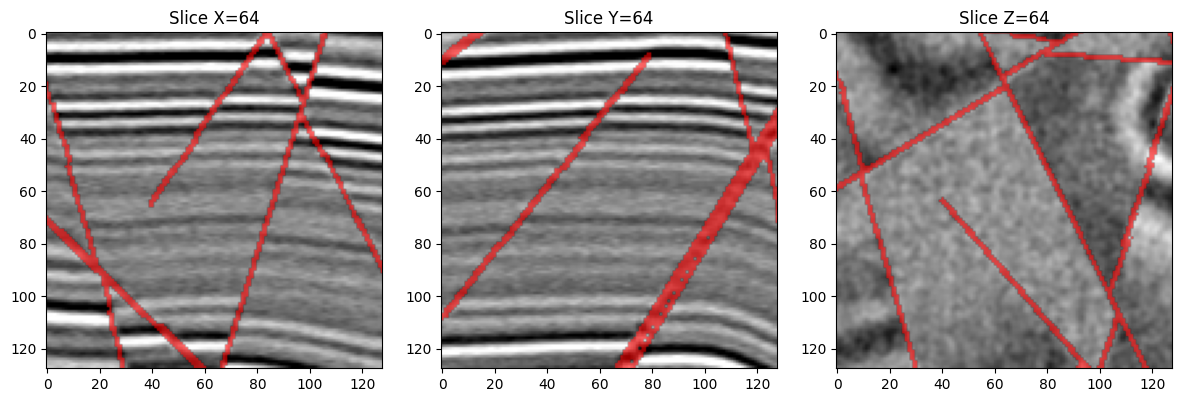

In [18]:
images, masks = next(iter(trainLoader))
img = images[0].squeeze().cpu().numpy()
msk = masks[0].squeeze().cpu().numpy()

print('xTrain Shape: ', img.shape)
print('yTrain Shape: ', msk.shape)
print('xTrain Range: ', (float(np.min(img)), float(np.max(img))))
print('yTrain Unique:', np.unique(msk).astype(int))

showTile(img)
showTile(img=img, mask=msk)

# TREINAMENTO

### Losses

In [19]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from torch import amp
gc.collect()

19397

In [20]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=network.multiclass)
loss

BinaryDiceFocalLoss(
  (_loss): DiceFocalLoss(
    (dice): DiceLoss()
    (focal): FocalLoss()
  )
)

### Scheduler

In [21]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [22]:
class Scheduler:
    def __new__(cls, selected, optimizer):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        if selected == 'cosine':
            return CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
        
        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [23]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau'):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size
        
        self.scheduler = Scheduler(scheduler, self.network.optimizer)
        self.early_stopping = EarlyStopping(patience=10, mode='max', min_delta=1e-4)

        self.use_amp = True 
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train()
            val_loss, val_iou     = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })
            
            self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)
            
            if self.early_stopping.ready(self.network.model, val_iou):
                break
            
        self.early_stopping.restore_best(self.network.model)

    def train(self, loader=trainLoader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                logits = self.network.model(imgs)
                loss = self.loss(logits, masks)
            
            train_loss += loss.item()
            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.model.parameters(), max_norm=1.0)

            self.scaler.step(self.network.optimizer)
            self.scaler.update()
            
            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1) 
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target) 
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int()) 
        
        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader=valLoader):
        self.network.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.network.model(imgs)
                    val_loss += self.loss(logits, masks).item()
                
                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())
        
        val_loss /= len(loader)
        val_iou  = self.network.iou.compute().item()
        return (val_loss, val_iou)


trainer = Trainer(network, loss, epochs=60, scheduler=scheduler)
trainer.start()

{'epoch': 1, 'train_loss': 0.915202454328537, 'val_loss': 0.8451029459635416, 'train_iou': 0.13887570798397064, 'val_iou': 0.2532324194908142, 'lr': 0.001}


{'epoch': 2, 'train_loss': 0.8073774719238281, 'val_loss': 0.7505752841631571, 'train_iou': 0.29417160153388977, 'val_iou': 0.3292231559753418, 'lr': 0.001}
(earling stopping) model improved to 0.329


{'epoch': 3, 'train_loss': 0.7169947707653046, 'val_loss': 0.67949511607488, 'train_iou': 0.35257017612457275, 'val_iou': 0.36074596643447876, 'lr': 0.001}
(earling stopping) model improved to 0.361


{'epoch': 4, 'train_loss': 0.6242679619789123, 'val_loss': 0.5674478014310201, 'train_iou': 0.41093334555625916, 'val_iou': 0.4530751407146454, 'lr': 0.001}
(earling stopping) model improved to 0.453


{'epoch': 5, 'train_loss': 0.5340034991502762, 'val_loss': 0.5082862575848898, 'train_iou': 0.4770887494087219, 'val_iou': 0.487918496131897, 'lr': 0.001}
(earling stopping) model improved to 0.488


...

{'epoch': 56, 'train_loss': 0.19778456702828406, 'val_loss': 0.23300407330195108, 'train_iou': 0.7494786381721497, 'val_iou': 0.7281442880630493, 'lr': 0.001}


{'epoch': 57, 'train_loss': 0.1957402516901493, 'val_loss': 0.2114819437265396, 'train_iou': 0.7503836750984192, 'val_iou': 0.7492678761482239, 'lr': 0.001}
(earling stopping) model improved to 0.749


{'epoch': 58, 'train_loss': 0.19475894138216973, 'val_loss': 0.21407607197761536, 'train_iou': 0.7511938810348511, 'val_iou': 0.7443066239356995, 'lr': 0.001}


{'epoch': 59, 'train_loss': 0.1938368272781372, 'val_loss': 0.21260219315687814, 'train_iou': 0.7527031302452087, 'val_iou': 0.7471570372581482, 'lr': 0.001}


{'epoch': 60, 'train_loss': 0.19018102571368217, 'val_loss': 0.21168910463651022, 'train_iou': 0.7559918761253357, 'val_iou': 0.7455141544342041, 'lr': 0.001}


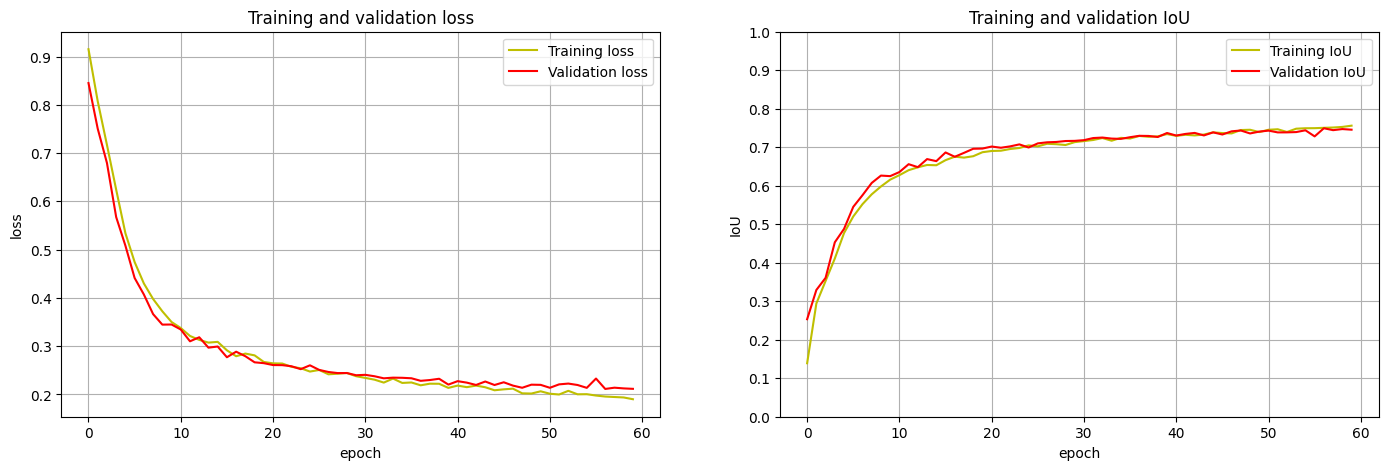

In [24]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Training loss')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(), plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot([h.get('train_iou') for h in history], 'y', label='Training IoU')
    plt.plot([h.get('val_iou')   for h in history], 'r', label='Validation IoU')
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])
    
    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [25]:
test_loss, test_iou = trainer.evaluate(loader=testLoader)
test_iou

0.7004402279853821

In [26]:
from torchmetrics.classification import MulticlassJaccardIndex

def getClasses(network, loader, save=None):
    iou_por_classe = MulticlassJaccardIndex(num_classes=network.classes, ignore_index=0, average='none').to(network.device)
    network.model.eval()

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(network.device)
            masks = masks.to(network.device).squeeze(1) 

            logits = network.model(imgs)
            preds  = torch.argmax(logits, dim=1) 
            iou_por_classe.update(preds, masks)

    ious = iou_por_classe.compute().cpu().numpy()
    ious = {str(i): float(val) for i, val in enumerate(ious)}
    
    ious = dict(sorted(ious.items(), key=lambda item: item[1], reverse=True))
    ious.update({'mean': test_iou})
    
    if '0' in ious:
        del ious['0']

    plt.figure(figsize=(17, 6))
    Plotter(ious)

    if save:
        plt.savefig(save)
        plt.close()  
    
    return ious


if network.multiclass:
    getClasses(network, testLoader)
    plt.show()

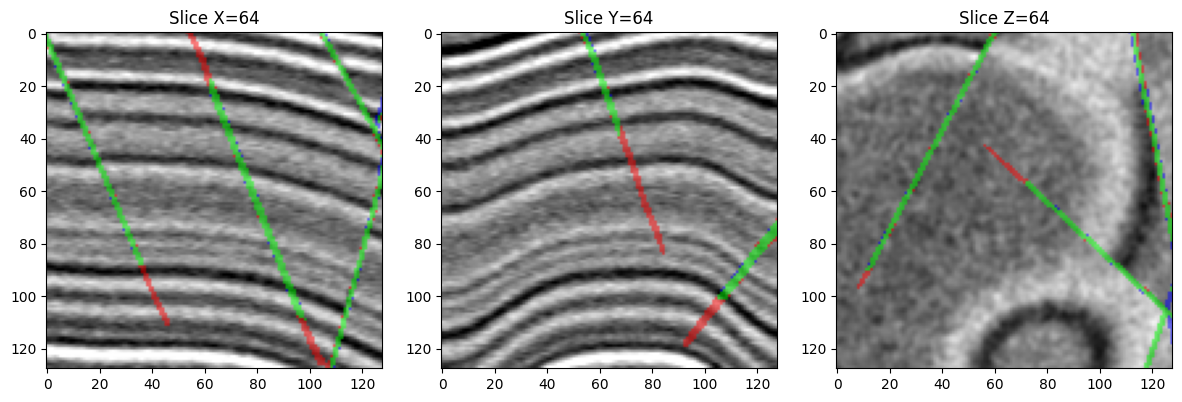

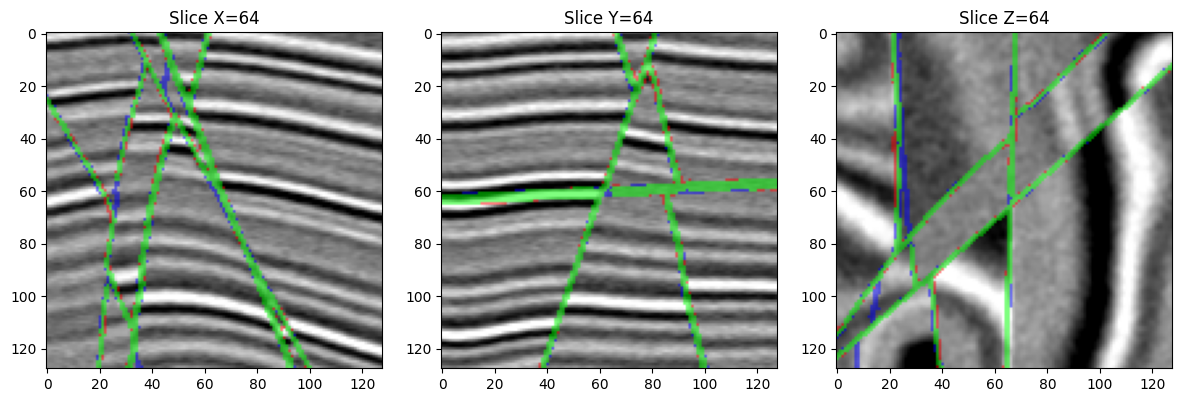

In [27]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    
    inters = (is_gt & is_pred)   # Acertos / Interseção

    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(testDataset), 2)):
    plotPrediction(index=i, dataset=testDataset, network=network)

# SALVANDO O MODELO

In [28]:
from datetime import datetime
import json, inspect

In [29]:
os.makedirs('Backup/', exist_ok=True)
files   = [f for f in os.listdir('Backup/') if f.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index  = indexes[-1] + 1
folder = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

'Backup/model_121'

In [30]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png')) if network.multiclass else {'mean': test_iou}
path    = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 20)):
    plotPrediction(index=i, dataset=testDataset, network=network, savePath=os.path.join(path, f'pred_{i}.png'))

In [31]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'val_iou':  trainer.history[-1].get('val_iou'),
        'test_iou': test_iou
    },

    'processing': OPTIONS,
    'model': model_options,
    'iou': iouData
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'), 
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)   

plotModel(model_data['history'], save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)

model saved in Backup/model_121
